In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [4]:
train=pd.read_csv('/kaggle/input/competitions/arabic-sentiment-ai-challenge/train.csv')
test=pd.read_csv('/kaggle/input/competitions/arabic-sentiment-ai-challenge/test.csv')
print(train.shape, test.shape)

(84443, 7) (21222, 6)


Sentiment
0    0.500468
1    0.499532
Name: proportion, dtype: float64


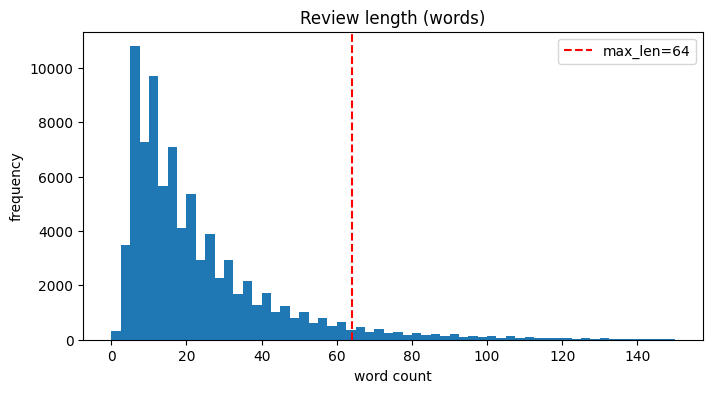

count    84443.000000
mean        24.012932
std         24.694019
min          2.000000
25%          9.000000
50%         17.000000
75%         30.000000
max        614.000000
Name: Review, dtype: float64
95th pct: 67.0 | max: 614

--- Nights ---
Nights
أقمت ليلة واحدة    35622
أقمت ليلتين        21959
أقمت 3 ليالي       11639
أقمت 4 ليالي        5985
أقمت 5 ليالي        3837
أقمت 6 ليالي        1858
أقمت 7 ليالي        1475
-                    738
Name: count, dtype: int64

--- Room_Type ---
Room_Type
-                        25030
غرفة قياسية مزدوجة        3678
غرفة مزدوجة               3313
شقة من غرفة نوم واحدة     2643
غرفة توأم                 2470
غرفة قياسية               2356
غرفة ديلوكس               2005
غرفة ثلاثية               1915
Name: count, dtype: int64

--- User_Type ---
User_Type
أسرة                           35105
زوج                            24647
مسافر منفرد                    13914
-                              10771
استوديو كلاسيكي - أسرة توأم        5
جنا

In [5]:
import matplotlib.pyplot as plt
print(train['Sentiment'].value_counts(normalize=True))

word_counts = train['Review'].astype(str).str.split().str.len()
plt.figure(figsize=(8,4))
plt.hist(word_counts, bins=60, range=(0, 150))
plt.axvline(64, color='red', linestyle='--', label='max_len=64')
plt.title('Review length (words)')
plt.xlabel('word count'); 
plt.ylabel('frequency'); 
plt.legend()
plt.show()

print(word_counts.describe())
print('95th pct:', word_counts.quantile(0.95), '| max:', word_counts.max())

for c in ['Nights', 'Room_Type', 'User_Type']:
    print(f'\n--- {c} ---')
    print(train[c].value_counts(dropna=False).head(8))

## What I found in EDA

- **Balanced classes** — about 50/50 split between positive and negative. No special handling needed for imbalance.
- **Review length** — most reviews are short (median 17 words), a few are very long (up to 614 words). Padding to 64 words covers almost all reviews without wasting space on rare long ones.
- **Extra columns** (`Nights`, `Room_Type`, `User_Type`) — these are messy and full of missing values (marked `-`). Not clean enough to use, so I'm only using the review text itself for the model.

In [6]:
import re

_ARABIC_DIACRITICS = re.compile(r'[\u0617-\u061A\u064B-\u0652\u0670\u0640]')

def clean_arabic(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'([.!؟])(?=[^\s])', r'\1 ', text)

    text = _ARABIC_DIACRITICS.sub('', text)               
    text = re.sub(r'[إأآا]', 'ا', text)                    
    text = re.sub(r'ى', 'ي', text)                         
    text = re.sub(r'ة', 'ه', text)                         
    text = re.sub(r'(.)\1{2,}', r'\1', text)               
    text = re.sub(r'[^\w\s“”\"،؟!]', ' ', text)         
    text = re.sub(r'([!؟])\s*\1+', r'\1', text)      
    text = re.sub(r'\s+', ' ', text).strip()             
    return text

In [7]:
train['clean_review'] = train['Review'].apply(clean_arabic)
test['clean_review'] = test['Review'].apply(clean_arabic)
train[['Review', 'clean_review']].head()

,Review,clean_review
0,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...,استثنائي سهوله انهاء المعامله في الاستقبال لاشيئ
1,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...,استثنائي انصح باختيار الاسويت و بالاخص غرفه رق...
2,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...,“استغرب تقييم الفندق كخمس نجوم” لا شي يستحق 2 ...
3,“جيدجداً”. الافطار جيد والسرير ممتاز ومريح واط...,“جيدجدا” الافطار جيد والسرير ممتاز ومريح واطلا...
4,“فندق ممتاز”. الاثاث، النظافه.,“فندق ممتاز” الاثاث، النظافه


In [8]:
from collections import Counter

def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train['clean_review'])
print("Vocab size:", len(vocab))

def encode(text, vocab, max_len=64):
    tokens = text.split()
    ids = [vocab.get(tok, vocab['<UNK>']) for tok in tokens]
    if len(ids) < max_len:
        ids = ids + [vocab['<PAD>']] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

train['input_ids'] = train['clean_review'].apply(lambda t: encode(t, vocab, max_len=64))
test['input_ids'] = test['clean_review'].apply(lambda t: encode(t, vocab, max_len=64))

print(train['input_ids'].iloc[0])
print(len(train['input_ids'].iloc[0]))  # should print 64

Vocab size: 45683
[2, 3, 4, 5, 6, 7, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
64


In [9]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train, test_size=0.1, random_state=SEED, stratify=train['Sentiment']
)
print(train_df.shape, val_df.shape)

class ReviewDataset(Dataset):
    def __init__(self, df, has_labels=True):
        self.input_ids = df['input_ids'].tolist()
        self.has_labels = has_labels
        if has_labels:
            self.labels = df['Sentiment'].tolist()

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        x = torch.tensor(self.input_ids[idx], dtype=torch.long)
        if self.has_labels:
            y = torch.tensor(self.labels[idx], dtype=torch.float)
            return x, y
        return x

train_dataset = ReviewDataset(train_df, has_labels=True)
val_dataset = ReviewDataset(val_df, has_labels=True)
test_dataset = ReviewDataset(test, has_labels=False)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

(75998, 9) (8445, 9)
torch.Size([64, 64]) torch.Size([64])


In [10]:
import torch.nn as nn

class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        hidden = hidden.squeeze(0)
        return self.fc(hidden).squeeze(1)

model = RNNClassifier(vocab_size=len(vocab)).to(device)
print(model)

RNNClassifier(
  (embedding): Embedding(45683, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [11]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), acc

N_EPOCHS = 3
for epoch in range(N_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    print(f"Epoch {epoch+1}/{N_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

Epoch 1/3 | train_loss=0.6923 | val_loss=0.6938 | val_acc=0.4924
Epoch 2/3 | train_loss=0.4292 | val_loss=0.3576 | val_acc=0.8475
Epoch 3/3 | train_loss=0.3169 | val_loss=0.3084 | val_acc=0.8664


In [12]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)   # LSTM returns (hidden, cell) tuple
        hidden = hidden.squeeze(0)
        return self.fc(hidden).squeeze(1)

model_lstm = LSTMClassifier(vocab_size=len(vocab)).to(device)
print(model_lstm)

optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)

N_EPOCHS = 3
for epoch in range(N_EPOCHS):
    train_loss = train_one_epoch(model_lstm, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_lstm, val_loader, criterion)
    print(f"Epoch {epoch+1}/{N_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

LSTMClassifier(
  (embedding): Embedding(45683, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Epoch 1/3 | train_loss=0.5787 | val_loss=0.5549 | val_acc=0.7298
Epoch 2/3 | train_loss=0.3404 | val_loss=0.2091 | val_acc=0.9274
Epoch 3/3 | train_loss=0.1620 | val_loss=0.1711 | val_acc=0.9366


In [13]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)  
        hidden = hidden.squeeze(0)
        return self.fc(hidden).squeeze(1)

model_gru = GRUClassifier(vocab_size=len(vocab)).to(device)
print(model_gru)

optimizer = optim.Adam(model_gru.parameters(), lr=1e-3)

N_EPOCHS = 3
for epoch in range(N_EPOCHS):
    train_loss = train_one_epoch(model_gru, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_gru, val_loader, criterion)
    print(f"Epoch {epoch+1}/{N_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

GRUClassifier(
  (embedding): Embedding(45683, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Epoch 1/3 | train_loss=0.4263 | val_loss=0.2190 | val_acc=0.9105
Epoch 2/3 | train_loss=0.1892 | val_loss=0.1809 | val_acc=0.9317
Epoch 3/3 | train_loss=0.1414 | val_loss=0.1653 | val_acc=0.9402


In [14]:
class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)
        hidden_cat = torch.cat((hidden[0], hidden[1]), dim=1) 
        return self.fc(hidden_cat).squeeze(1)

model_bigru = BiGRUClassifier(vocab_size=len(vocab)).to(device)
print(model_bigru)

optimizer = optim.Adam(model_bigru.parameters(), lr=1e-3)

N_EPOCHS = 3
for epoch in range(N_EPOCHS):
    train_loss = train_one_epoch(model_bigru, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_bigru, val_loader, criterion)
    print(f"Epoch {epoch+1}/{N_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

BiGRUClassifier(
  (embedding): Embedding(45683, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
Epoch 1/3 | train_loss=0.2005 | val_loss=0.1574 | val_acc=0.9394
Epoch 2/3 | train_loss=0.1237 | val_loss=0.1495 | val_acc=0.9433
Epoch 3/3 | train_loss=0.0870 | val_loss=0.1670 | val_acc=0.9441


In [15]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, gru_output, mask):
        # gru_output: (batch, seq_len, hidden_dim)
        scores = self.attn(gru_output).squeeze(-1)        
        scores = scores.masked_fill(mask == 0, -1e9)        
        weights = torch.softmax(scores, dim=1)            
        context = torch.bmm(weights.unsqueeze(1), gru_output).squeeze(1)  
        return context, weights

class BiGRUAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = Attention(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        mask = (x != self.pad_idx).float()         
        embedded = self.embedding(x)
        gru_output, _ = self.gru(embedded)            
        context, attn_weights = self.attention(gru_output, mask)
        return self.fc(context).squeeze(1)

model_attn = BiGRUAttentionClassifier(vocab_size=len(vocab)).to(device)
print(model_attn)

optimizer = optim.Adam(model_attn.parameters(), lr=1e-3)

N_EPOCHS = 3
for epoch in range(N_EPOCHS):
    train_loss = train_one_epoch(model_attn, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_attn, val_loader, criterion)
    print(f"Epoch {epoch+1}/{N_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

BiGRUAttentionClassifier(
  (embedding): Embedding(45683, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
Epoch 1/3 | train_loss=0.2034 | val_loss=0.1573 | val_acc=0.9389
Epoch 2/3 | train_loss=0.1264 | val_loss=0.1511 | val_acc=0.9429
Epoch 3/3 | train_loss=0.0888 | val_loss=0.1673 | val_acc=0.9415


In [16]:
!pip install -q transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LEN = 64
BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

bert_train_df, bert_val_df = train_test_split(
    train, test_size=0.1, random_state=SEED, stratify=train['Sentiment']
)
print(bert_train_df.shape, bert_val_df.shape)

class BertReviewDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.encodings = tokenizer(
            list(texts),
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_bert_dataset = BertReviewDataset(bert_train_df['Review'].tolist(), bert_train_df['Sentiment'].tolist())
val_bert_dataset = BertReviewDataset(bert_val_df['Review'].tolist(), bert_val_df['Sentiment'].tolist())

train_bert_loader = DataLoader(train_bert_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_bert_loader = DataLoader(val_bert_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_bert_loader))
print({k: v.shape for k, v in batch.items()})

optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

def train_one_epoch_bert(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch['input_ids'].size(0)
    return total_loss / len(loader.dataset)

def evaluate_bert(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item() * batch['input_ids'].size(0)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), acc

N_EPOCHS = 2
for epoch in range(N_EPOCHS):
    train_loss = train_one_epoch_bert(bert_model, train_bert_loader, optimizer)
    val_loss, val_acc = evaluate_bert(bert_model, val_bert_loader)
    print(f"Epoch {epoch+1}/{N_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

bert_model.save_pretrained('/content/arabert_finetuned')
tokenizer.save_pretrained('/content/arabert_finetuned')

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

(75998, 9) (8445, 9)
{'input_ids': torch.Size([16, 64]), 'token_type_ids': torch.Size([16, 64]), 'attention_mask': torch.Size([16, 64]), 'labels': torch.Size([16])}
Epoch 1/2 | train_loss=0.1335 | val_loss=0.1164 | val_acc=0.9608
Epoch 2/2 | train_loss=0.1021 | val_loss=0.1147 | val_acc=0.9621


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/arabert_finetuned/tokenizer_config.json',
 '/content/arabert_finetuned/tokenizer.json')

In [17]:
bert_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in val_bert_loader:
        batch_gpu = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        outputs = bert_model(**batch_gpu)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

bert_val_df_copy = bert_val_df.copy()
bert_val_df_copy['pred'] = all_preds

misclassified = bert_val_df_copy[bert_val_df_copy['pred'] != bert_val_df_copy['Sentiment']]
print(f"Misclassified: {len(misclassified)} / {len(bert_val_df_copy)} ({len(misclassified)/len(bert_val_df_copy)*100:.1f}%)")

misclassified[['Review', 'Sentiment', 'pred']].sample(10, random_state=1)

Misclassified: 320 / 8445 (3.8%)


,Review,Sentiment,pred
8463,“فندق ممتاز”. فندق ممتاز. لا شي,0,1
915,“فندق جميل بشكل عام والطعام لذيذ”. الفندق جميل...,0,1
79194,“ناصر ناصر انسان متميز في الاستقبال وله جزيل ا...,0,1
50938,“الفندق بهذه المواصفات مقارنة بالسعر ممتاز”. ك...,0,1
58149,“رائع”. الموقع. عدم التحدث باللغة العربية الا...,0,1
20156,“جيد ولكن الاداره هنديه والرسبشن مصري يعني خلي...,0,1
59505,“الاحساء - المنطقة الشرقية”. . نقل الباصات للح...,0,1
61001,“رحلت دبي”. الفندق جميل ونظيف. ولكن يعيبه ان ل...,0,1
15374,“فندق للشباب ممتاز”. . قدم الفرش والأثاث ولايو...,0,1
1004,“اقامه لاباس فيها لولا تسليمنا غرفه بدون اناره...,0,1


Most mistakes happen when a review has mixed feelings — nice at the start, complaints later (or the opposite). The model tends to lean too much on the opening line.

A few reviews mix in English words, which might trip it up a bit.

Some labels also look just plain wrong — like a review saying "won't visit again" but marked positive.

So most errors aren't really the model's fault — they're genuinely tricky reviews or bad labels.

In [18]:
class BertTestDataset(Dataset):
    def __init__(self, texts):
        self.encodings = tokenizer(
            list(texts),
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

test_bert_dataset = BertTestDataset(test['Review'].tolist())
test_bert_loader = DataLoader(test_bert_dataset, batch_size=16, shuffle=False)

bert_model.eval()
test_preds = []

with torch.no_grad():
    for batch in test_bert_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())

print(len(test_preds)) 

sub = pd.DataFrame({'Review_ID': test['Review_ID'], 'Sentiment': test_preds})
sub.to_csv('submission.csv', index=False)
sub.head()

21222


,Review_ID,Sentiment
0,241096,1
1,397912,0
2,323390,0
3,365977,1
4,321051,1


In [19]:
sample_sub = pd.read_csv('/kaggle/input/competitions/arabic-sentiment-ai-challenge/sample_submission.csv')
print(sub.shape, sample_sub.shape)
print(sub.columns.tolist(), sample_sub.columns.tolist())
print(sub['Sentiment'].value_counts(normalize=True))

(21222, 2) (21222, 2)
['Review_ID', 'Sentiment'] ['Review_ID', 'Sentiment']
Sentiment
1    0.524833
0    0.475167
Name: proportion, dtype: float64
